In [50]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [51]:
data =pd.read_excel("Data_Train.xlsx")
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [52]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [54]:
data.dropna(inplace=True)

In [55]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [56]:
data["Date_of_Journey"]=pd.to_datetime(data["Date_of_Journey"],format="%d/%m/%Y")

In [57]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time                   object
Arrival_Time               object
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [58]:
data['Day']=data["Date_of_Journey"].dt.day
data['Month']=data["Date_of_Journey"].dt.month
data['Year']=data["Date_of_Journey"].dt.year

In [59]:
data.drop("Date_of_Journey",axis=1,inplace=True)

In [60]:
data.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [61]:
data['Dep_Time']=pd.to_datetime(data['Dep_Time'])

C:\Users\vishn\AppData\Local\Temp\ipykernel_25216\3623356568.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dep_Time']=pd.to_datetime(data['Dep_Time'])


In [62]:
data['Dep_Hour']=pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Minute']=pd.to_datetime(data['Dep_Time']).dt.minute

In [63]:
data.drop('Dep_Time',axis=1,inplace=True)

In [64]:
data.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [65]:
data['Arrival_Time']=pd.to_datetime(data['Arrival_Time'])

C:\Users\vishn\AppData\Local\Temp\ipykernel_25216\3394994777.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Arrival_Time']=pd.to_datetime(data['Arrival_Time'])


In [66]:
data['Arrival_hour']=pd.to_datetime(data['Arrival_Time']).dt.hour
data['Arrival_minute']=pd.to_datetime(data['Arrival_Time']).dt.minute
data['Arrival_month']=pd.to_datetime(data['Arrival_Time']).dt.month

In [67]:
data.drop('Arrival_Time',axis=1,inplace=True)

In [68]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Minute,Arrival_hour,Arrival_minute,Arrival_month
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,2
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,2


In [69]:
data['Duration']=pd.to_timedelta(data['Duration'])
data['Duration_hours']=data['Duration'].dt.components.hours
data['Duration_minutes']=data['Duration'].dt.components.minutes

In [70]:
data.drop('Duration',axis=1,inplace=True)

In [71]:
data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Minute,Arrival_hour,Arrival_minute,Arrival_month,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,22,20,1,10,3,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,5,50,13,15,2,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,9,25,4,25,6,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,18,5,23,30,2,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,16,50,21,35,2,4,45


In [72]:
# Clean up Total_Stops column
data['Total_Stops'] = (
    data['Total_Stops']
    .str.replace(' stops', '', regex=False)
    .str.replace(' stop', '', regex=False)
    .str.replace('non-stop', '0', regex=False)
    .astype(int)
)

data.head()


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Minute,Arrival_hour,Arrival_minute,Arrival_month,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,22,20,1,10,3,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,5,50,13,15,2,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,2019,9,25,4,25,6,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,2019,18,5,23,30,2,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,2019,16,50,21,35,2,4,45


In [73]:
data['Route_1'] = data['Route'].str.split('→').str[0].str.strip()
data['Route_2'] = data['Route'].str.split('→').str[1].str.strip()
data['Route_3'] = data['Route'].str.split('→').str[2].str.strip()
data['Route_4'] = data['Route'].str.split('→').str[3].str.strip()
data['Route_5'] = data['Route'].str.split('→').str[4].str.strip()

In [74]:
data['Route_1']=data['Route_1'].fillna('None')
data['Route_2']=data['Route_2'].fillna('None') 
data['Route_3']=data['Route_3'].fillna('None')
data['Route_4']=data['Route_4'].fillna('None')
data['Route_5']=data['Route_5'].fillna('None')

In [75]:
data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,...,Arrival_hour,Arrival_minute,Arrival_month,Duration_hours,Duration_minutes,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,...,1,10,3,2,50,BLR,DEL,None,None,None
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,...,13,15,2,7,25,CCU,IXR,BBI,BLR,None
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,2019,...,4,25,6,19,0,DEL,LKO,BOM,COK,None
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,2019,...,23,30,2,5,25,CCU,NAG,BLR,None,None
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,2019,...,21,35,2,4,45,BLR,NAG,DEL,None,None


In [76]:
data.drop('Route',axis=1,inplace=True)

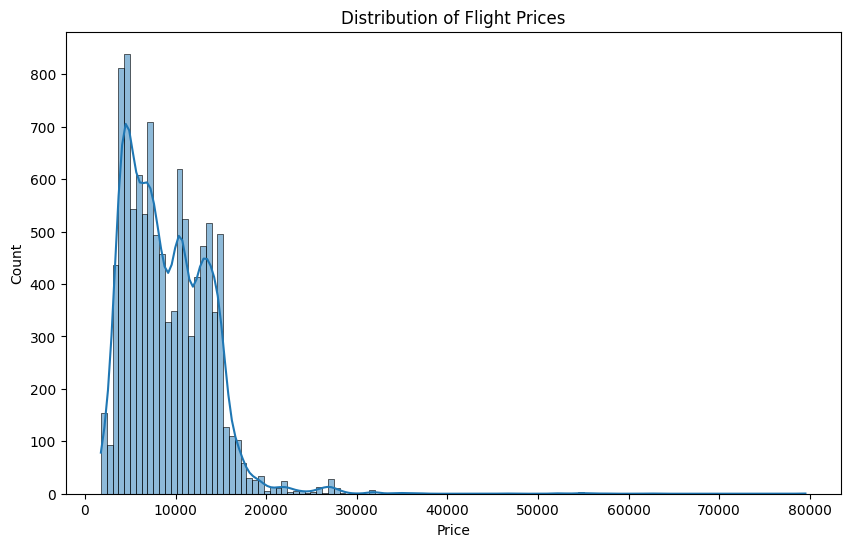

In [77]:
plt.figure(figsize=(10,6))
sns.histplot(data['Price'], kde=True)
plt.title('Distribution of Flight Prices')
plt.show()

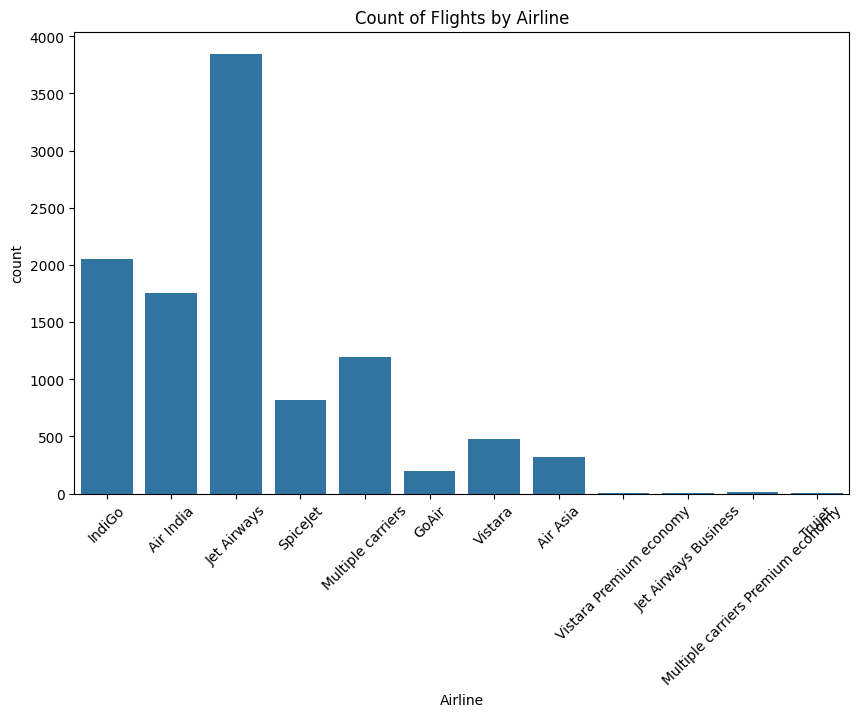

In [78]:
plt.figure(figsize=(10,6))
sns.countplot(x='Airline', data=data)
plt.title('Count of Flights by Airline') 
plt.xticks(rotation=45)   
plt.show()

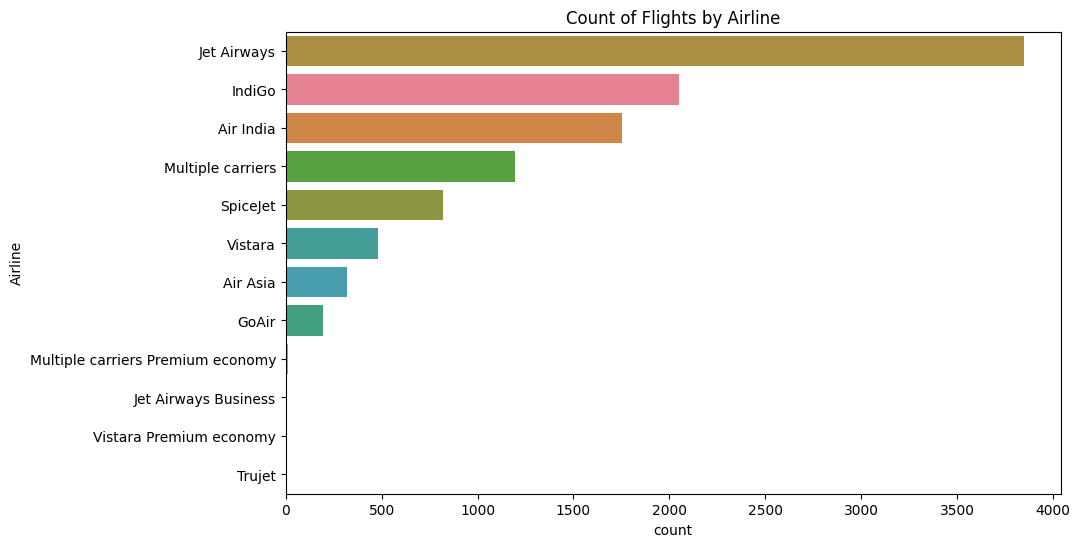

In [79]:
#plot the airline counts  
plt.figure(figsize=(10,6))
#make a horizantal bar plot of airline counts
sns.countplot(y=data['Airline'],order=data['Airline'].value_counts().index,hue=data['Airline'])
plt.title('Count of Flights by Airline')
plt.show()

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [81]:
data.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,...,Arrival_hour,Arrival_minute,Arrival_month,Duration_hours,Duration_minutes,Route_1,Route_2,Route_3,Route_4,Route_5
0,3,0,5,0,8,3897,24,3,2019,22,...,1,10,3,2,50,0,10,21,10,4
1,1,3,0,2,8,7662,1,5,2019,5,...,13,15,2,7,25,2,20,1,3,4
2,4,2,1,2,8,13882,9,6,2019,9,...,4,25,6,19,0,3,27,4,5,4
3,3,3,0,1,8,6218,12,5,2019,18,...,23,30,2,5,25,2,29,3,10,4
4,3,0,5,1,8,13302,1,3,2019,16,...,21,35,2,4,45,0,29,7,10,4


In [82]:
data.describe()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,...,Arrival_hour,Arrival_minute,Arrival_month,Duration_hours,Duration_minutes,Route_1,Route_2,Route_3,Route_4,Route_5
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.0,10682.000000,...,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,3.966205,1.952256,1.436154,0.824190,7.392998,9087.214567,13.509081,4.708575,2019.0,12.491013,...,13.349186,24.690601,3.119921,7.728515,28.326624,2.019378,9.666823,10.470511,9.227017,3.987456
std,2.352090,1.177276,1.474845,0.675229,1.214254,4611.548810,8.479363,1.164408,0.0,5.748820,...,6.859317,16.506808,1.544017,6.419127,16.945817,1.206239,6.507996,7.676270,1.907624,0.200719
min,0.000000,0.000000,0.000000,0.000000,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,...,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,0.000000,8.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,...,8.000000,10.000000,2.000000,2.000000,15.000000,1.000000,6.000000,4.000000,10.000000,4.000000
50%,4.000000,2.000000,1.000000,1.000000,8.000000,8372.000000,12.000000,5.000000,2019.0,11.000000,...,14.000000,25.000000,2.000000,6.000000,30.000000,2.000000,7.000000,6.000000,10.000000,4.000000
75%,4.000000,3.000000,2.000000,1.000000,8.000000,12373.000000,21.000000,6.000000,2019.0,18.000000,...,19.000000,35.000000,5.000000,12.000000,45.000000,3.000000,10.000000,21.000000,10.000000,4.000000
max,11.000000,4.000000,5.000000,4.000000,9.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,...,23.000000,55.000000,6.000000,23.000000,55.000000,4.000000,39.000000,26.000000,11.000000,5.000000


In [83]:
print('Mean:', data['Price'].mean())
print('Median:', data['Price'].median())
print('Mode:', data['Price'].mode()[0])

Mean: 9087.21456656057
Median: 8372.0
Mode: 10262


In [85]:
# Split the data into features and target variable
X = data.drop('Price', axis=1)
y = data['Price']

In [86]:
# DATA preprocessing and model training 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
Lr=LinearRegression()
Lr.fit(X_train,y_train)
y_pred = Lr.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 2291.972374878011
Mean Squared Error: 10776094.589620728
R-squared: 0.5002288080684881


In [87]:
#decision tree regressor
from sklearn.tree import DecisionTreeRegressor
Dtr=DecisionTreeRegressor()
Dtr.fit(X_train,y_train)
y_pred_dtr = Dtr.predict(X_test)
mae_dtr = mean_absolute_error(y_test, y_pred_dtr)
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
r2_dtr = r2_score(y_test, y_pred_dtr)
print('Decision Tree Regressor - Mean Absolute Error:', mae_dtr)
print('Decision Tree Regressor - Mean Squared Error:', mse_dtr)
print('Decision Tree Regressor - R-squared:', r2_dtr)


Decision Tree Regressor - Mean Absolute Error: 680.4279363593823
Decision Tree Regressor - Mean Squared Error: 3466493.10025737
Decision Tree Regressor - R-squared: 0.8392317945866359


In [90]:
#SVR
from sklearn.svm import SVR
svr = SVR(kernel='linear')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print('SVR - Mean Absolute Error:', mae_svr)
print('SVR - Mean Squared Error:', mse_svr)
print('SVR - R-squared:', r2_svr)


SVR - Mean Absolute Error: 2263.905285086549
SVR - Mean Squared Error: 11805592.941167228
SVR - R-squared: 0.45248297455107567


In [93]:
#KNN
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print('KNN - Mean Absolute Error:', mae_knn)
print('KNN - Mean Squared Error:', mse_knn)
print('KNN - R-squared:', r2_knn)

KNN - Mean Absolute Error: 1543.1637810014038
KNN - Mean Squared Error: 7414606.992616857
KNN - R-squared: 0.6561270928363045


In [94]:
#random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test) 
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print('Random Forest Regressor - Mean Absolute Error:', mae_rf)
print('Random Forest Regressor - Mean Squared Error:', mse_rf)
print('Random Forest Regressor - R-squared:', r2_rf)

Random Forest Regressor - Mean Absolute Error: 603.7275899904183
Random Forest Regressor - Mean Squared Error: 1909208.0765053781
Random Forest Regressor - R-squared: 0.911455194819894


In [95]:
#all models evaluation
models = ['Linear Regression', 'Decision Tree Regressor', 'SVR', 'KNN', 'Random Forest Regressor']
mae_values = [mae, mae_dtr, mae_svr, mae_knn, mae_rf]
mse_values = [mse, mse_dtr, mse_svr, mse_knn    , mse_rf]
r2_values = [r2, r2_dtr, r2_svr, r2_knn, r2_rf]
evaluation_df = pd.DataFrame({'Model': models, 'MAE': mae_values, 'MSE': mse_values, 'R-squared': r2_values})
print(evaluation_df)

                     Model          MAE           MSE  R-squared
0        Linear Regression  2291.972375  1.077609e+07   0.500229
1  Decision Tree Regressor   680.427936  3.466493e+06   0.839232
2                      SVR  2263.905285  1.180559e+07   0.452483
3                      KNN  1543.163781  7.414607e+06   0.656127
4  Random Forest Regressor   603.727590  1.909208e+06   0.911455


In [96]:
#save the best model
import joblib 
joblib.dump(rf, 'best_model.pkl')

['best_model.pkl']